 **Online Retail Data Cleaning and Exploratory Data Analysis**

 Project Objective

This project analyzes an online retail transaction dataset to understand sales performance, customer purchasing behavior, product performance, and country-level revenue contribution.

The analysis covers:

- Dataset Understanding
- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Business Insights

 # **Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

raw_df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

df = raw_df.copy()

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [2]:
raw_df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

print(raw_df.shape)

(541909, 8)


## Task 1: Dataset Understanding

The first step is to understand the dataset by examining its structure, dimensions, data types, and key features.

This helps identify potential data quality issues and provides context before cleaning and analysis.

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Initial Data Inspection

The first five rows were examined to understand the structure of the dataset.

Each record represents a transaction line item containing:

- Invoice Number
- Product Code
- Product Description
- Quantity Purchased
- Invoice Date
- Unit Price
- Customer ID
- Customer Country

This initial inspection helps verify that the dataset has loaded correctly and provides an understanding of the available variables.

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 541909
Columns: 8


### Dataset Structure
This dataset comprises of 541,909 across 8 columns. Its' substantial volume makes it highly effective for for driving sales analytics, evaluating product performance and modeling customer behaviour.

In [6]:
numerical_features = df.select_dtypes(include=['number']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Quantity', 'UnitPrice', 'CustomerID']

Categorical Features:
['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']


### Feature Classification

The dataset contains both numerical and categorical variables.

Numerical features will be used for quantitative analysis such as revenue, pricing, and purchase quantities.

Categorical features will be used to analyze customer locations, products, and transaction details.

In [7]:
for col in df.columns:
    print(col, ":", df[col].nunique())

InvoiceNo : 25900
StockCode : 4070
Description : 4223
Quantity : 722
InvoiceDate : 23260
UnitPrice : 1630
CustomerID : 4372
Country : 38


### Potential Unique Identifiers

The following columns were reviewed as potential identifiers:

- InvoiceNo (Transaction Identifier)
- StockCode (Product Identifier)
- CustomerID (Customer Identifier)
- Quantity (Total no of goods sold Identifier)
- Country  (Country Identifier)

No single column uniquely identifies every record because each invoice may contain multiple products.

## Task 2: Data Cleaning

Data cleaning is a critical step in the data analysis process. The objective is to identify and correct data quality issues that may affect the accuracy of analysis and visualizations.

The following cleaning activities will be performed:

1. Missing Value Analysis
2. Duplicate Record Detection and Removal
3. Data Standardization
4. Data Validation
5. Cleaning Summary Documentation

Each action taken during the cleaning process is documented and justified to maintain transparency.


In [8]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': round((missing_values / len(df)) * 100, 2)
})

missing_summary

,Missing Values,Percentage (%)
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


### Missing Value Treatment

Two columns were identified with missing values:

| Column      | Missing Values | Percentage |
| ----------- | -------------- | ---------- |
| Description | 1,454          | 0.27%      |
| CustomerID  | 135,080        | 24.93%     |

Description

Method chosen: Remove rows

Reason: Only 1,454 rows (0.27%) are missing, which is a very small proportion of the dataset. The values cannot be reliably inferred, and removing them has minimal impact on the analysis.

CustomerID

Method chosen: Retain missing values

Reason: 135,080 rows (24.93%) are missing. Removing these records would result in substantial data loss and could distort sales and revenue analysis. CustomerID is not essential for product and revenue level analysis.

In [9]:
# Remove rows with missing product descriptions

rows_before = len(df)

df = df.dropna(subset=['Description'])

rows_after = len(df)

print("Rows removed:", rows_before - rows_after)
print("Rows remaining:", rows_after)

Rows removed: 1454
Rows remaining: 540455


### Missing Value Cleaning Outcome

The missing value treatment was successfully applied.

Rows containing missing values in the **Description** column were removed because product descriptions are important for product-level analysis and the number of affected records was minimal.

A total of **1,454 records** were removed from the dataset.

Missing values in the **CustomerID** column were retained because they represented approximately **25% of all records**. Removing these observations would have resulted in substantial data loss and could have negatively affected sales and revenue analysis.

After cleaning, the dataset retained the majority of transactions while improving overall data quality.


### Duplicate Record Analysis

Duplicate records were investigated to determine whether the dataset contained repeated transactions that could affect the accuracy of the analysis.

Duplicate records can lead to inflated sales figures, incorrect customer counts, and misleading business insights. Therefore, identifying and addressing duplicates is an important part of the data cleaning process.

The number of duplicate rows will be calculated before deciding whether removal is necessary.


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


### Duplicate Record Treatment

A total of **5,268 duplicate rows** were identified in the dataset.

Duplicate records can result in overstated transaction counts, inaccurate revenue calculations, and misleading analytical results. Since each row in the dataset represents a transaction line item, retaining duplicate records would distort the analysis.

Therefore, duplicate rows were removed to improve data quality and ensure that each transaction record is represented only once in the dataset.


In [11]:
rows_before = len(df)

df = df.drop_duplicates()

rows_after = len(df)

duplicates_removed = rows_before - rows_after

print("Duplicates removed:", duplicates_removed)
print("Remaining rows:", rows_after)

Duplicates removed: 5268
Remaining rows: 535187


### Duplicate Record Cleaning Outcome

The duplicate removal process was successfully completed.

A total of **5,268 duplicate records** were removed from the dataset.

Removing duplicate records helps ensure that sales figures, customer activity, and product performance metrics are not overstated due to repeated transaction entries.

The cleaned dataset now contains only unique transaction records.


### Data Standardization

Data standardization will be performed to ensure consistency across the dataset.

Standardization improves data quality by ensuring that dates, text fields, column names, and data types follow a consistent format. This helps prevent errors during analysis and improves the readability of the dataset.

The following standardization activities will be  performed:

* Column name standardization
* Date format standardization
* Text formatting standardization
* Data type validation


In [12]:
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [13]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

#### Column Name Standardization

Column names were standardized by:

* Converting all names to lowercase
* Replacing spaces with underscores
* Removing unnecessary whitespace

This naming convention improves readability and makes it easier to reference columns during analysis.


In [14]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

df['invoicedate'].head()

,invoicedate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


In [15]:
df['invoicedate'].dtype

dtype('<M8[ns]')

#### Date Format Standardization

The InvoiceDate column was converted from text format to a datetime format.



In [16]:
df['description'] = df['description'].str.strip().str.upper()

In [17]:
df['country'] = df['country'].str.strip().str.title()

#### Text Formatting Standardization

Text fields were standardized to improve consistency.

* Product descriptions were converted to uppercase.
* Country names were converted to title case.
* Leading and trailing spaces were removed where applicable.

This helps prevent duplicate categories caused by inconsistent text formatting.


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 535187 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    535187 non-null  object        
 1   stockcode    535187 non-null  object        
 2   description  535187 non-null  object        
 3   quantity     535187 non-null  int64         
 4   invoicedate  535187 non-null  datetime64[ns]
 5   unitprice    535187 non-null  float64       
 6   customerid   401604 non-null  float64       
 7   country      535187 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.7+ MB


#### Data Type Validation

The dataset was reviewed to ensure that each column was assigned an appropriate data type.

Special attention was given to the InvoiceDate column, which was converted to a datetime format to support time-series analysis.

The remaining columns were confirmed to have suitable data types for analytical processing.


### Data Validation

Data validation will be performed to identify invalid values, inconsistent records, incorrect formats, and unusual observations that could affect the quality of the analysis.

The dataset will be examined for:

* Negative quantities
* Invalid unit prices
* Cancelled transactions
* Potential outliers and anomalies

The findings reviewed and appropriate actions will be taken based on the business context of the dataset.


In [19]:
negative_quantity = df[df['quantity'] < 0]

print("Negative Quantity Records:", len(negative_quantity))

Negative Quantity Records: 9725


In [21]:
negative_quantity.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
141,C536379,D,DISCOUNT,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [22]:
invalid_price = df[df['unitprice'] <= 0]

print("Invalid Price Records:", len(invalid_price))

Invalid Price Records: 1058


In [23]:
invalid_price.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
6391,536941,22734,AMAZON,20,2010-12-03 12:08:00,0.0,NaN,United Kingdom
6392,536942,22139,AMAZON,15,2010-12-03 12:08:00,0.0,NaN,United Kingdom
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
13217,537425,84968F,CHECK,-20,2010-12-06 15:35:00,0.0,NaN,United Kingdom


In [24]:
cancelled_orders = df[df['invoiceno'].astype(str).str.startswith('C')]

print("Cancelled Orders:", len(cancelled_orders))

Cancelled Orders: 9251


In [25]:
df['quantity'].describe()

,quantity
count,535187.000000
mean,9.671593
std,219.059056
min,-80995.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,80995.000000


### Data Validation Findings

Several data quality issues were identified during validation:

* 9,725 records contained negative quantities.
* 1,058 records contained unit prices less than or equal to zero.
* 9,251 transactions were identified as cancelled orders based on invoice numbers beginning with the letter "C".

The quantity distribution also revealed extreme minimum and maximum values ranging from -80,995 to 80,995 units.

Further investigation indicated that most negative quantities were associated with cancelled or returned transactions. These records do not represent completed sales and therefore require special consideration before analysis.


In [26]:
rows_before = len(df)

df = df[~df['invoiceno'].astype(str).str.startswith('C')]

rows_after = len(df)

print("Cancelled transactions removed:", rows_before - rows_after)

Cancelled transactions removed: 9251


### Treatment of Cancelled Transactions

Cancelled transactions were identified using invoice numbers that begin with the letter "C".

These records represent order cancellations or returns rather than completed sales transactions.

Because the objective of this analysis is to evaluate actual sales performance and customer purchasing behavior, cancelled transactions were removed from the dataset.

Removing these records helps ensure that revenue, quantity sold, and customer activity metrics accurately reflect completed transactions.


In [27]:
df[df['unitprice'] <= 0].head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
6391,536941,22734,AMAZON,20,2010-12-03 12:08:00,0.0,NaN,United Kingdom
6392,536942,22139,AMAZON,15,2010-12-03 12:08:00,0.0,NaN,United Kingdom
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
13217,537425,84968F,CHECK,-20,2010-12-06 15:35:00,0.0,NaN,United Kingdom


### Treatment of Invalid Unit Prices

A total of 1,058 records were identified with unit prices less than or equal to zero.

Since the objective of this analysis is to evaluate sales performance and customer purchasing behavior, records with non-positive unit prices were removed from the dataset.

Removing these records helps ensure that revenue calculations and product performance metrics accurately reflect valid sales transactions.


In [28]:
rows_before = len(df)

df = df[df['unitprice'] > 0]

rows_after = len(df)

print("Invalid price records removed:", rows_before - rows_after)
print("Remaining rows:", rows_after)

Invalid price records removed: 1058
Remaining rows: 524878


In [29]:
print("Negative Quantity Records Remaining:",
      len(df[df['quantity'] < 0]))

Negative Quantity Records Remaining: 0


### Data Validation Outcome

Data validation identified several anomalies within the dataset, including cancelled transactions, negative quantities, and records with non-positive unit prices.

Cancelled transactions were removed because they do not represent completed sales activities.

Records with unit prices less than or equal to zero were also removed because they do not contribute to revenue generation and may represent administrative or incomplete transactions.

These cleaning actions improved the reliability of the dataset and ensured that subsequent analyses would be based on valid sales transactions.


In [30]:
cleaning_summary = pd.DataFrame({
    'Issue Found': [
        'Missing Values (Description)',
        'Missing Values (CustomerID)',
        'Duplicate Records',
        'Cancelled Transactions',
        'Invalid Unit Prices',
        'Column Name Standardization',
        'Date Standardization',
        'Text Standardization'
    ],
    'Action Taken': [
        'Removed 1,454 records',
        'Retained missing values',
        'Removed 5,268 duplicate rows',
        'Removed cancelled invoices',
        'Removed records with UnitPrice <= 0',
        'Converted to lowercase and underscores',
        'Converted InvoiceDate to datetime',
        'Standardized Description and Country fields'
    ]
})

cleaning_summary

,Issue Found,Action Taken
0,Missing Values (Description),"Removed 1,454 records"
1,Missing Values (CustomerID),Retained missing values
2,Duplicate Records,"Removed 5,268 duplicate rows"
3,Cancelled Transactions,Removed cancelled invoices
4,Invalid Unit Prices,Removed records with UnitPrice <= 0
5,Column Name Standardization,Converted to lowercase and underscores
6,Date Standardization,Converted InvoiceDate to datetime
7,Text Standardization,Standardized Description and Country fields


## Cleaning Summary

The data cleaning process successfully addressed issues related to missing values, duplicate records, cancelled transactions, invalid pricing, and data standardization.

The cleaning actions improved data quality and ensured that the dataset accurately represents valid retail sales transactions.

The cleaned dataset is now suitable for exploratory data analysis, visualization, and business insight generation.


In [31]:
df.to_csv('cleaned_online_retail.csv', index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Task 3: Exploratory Data Analysis (EDA)

Following data cleaning, exploratory data analysis will be performed to understand patterns, trends, and relationships within the dataset.

The objective of this analysis is to uncover meaningful business insights related to product performance, customer behavior, sales trends, and revenue generation.

A revenue column will be created to measure the monetary value of each transaction and support sales analysis.


In [32]:
df['revenue'] = df['quantity'] * df['unitprice']

df[['quantity', 'unitprice', 'revenue']].head()

,quantity,unitprice,revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


### Summary Statistics

Summary statistics will be generated to understand the distribution and central tendency of numerical variables within the dataset.

Key statistical measures include:

* Mean
* Median
* Minimum
* Maximum
* Standard Deviation

These metrics help identify patterns and potential anomalies.


In [33]:
df[['quantity', 'unitprice', 'revenue']].describe()

,quantity,unitprice,revenue
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


### Summary Statistics Findings

Summary statistics were generated for the numerical variables Quantity, UnitPrice, and Revenue.

The results provide insight into the distribution of transaction quantities, product pricing, and sales revenue.

The analysis revealed substantial variability across transactions, particularly in revenue and quantity, suggesting differences in customer purchasing behavior and product demand.

The presence of large maximum values relative to the mean indicates that some transactions were significantly larger than typical purchases, which is common in retail sales datasets.


### Analysis 1: Top Selling Products

This analysis identifies the products with the highest quantity sold.

Understanding top-selling products helps businesses optimize inventory management, marketing efforts, and product strategy.


In [34]:
top_products = (
    df.groupby('description')['quantity']
      .sum()
      .sort_values(ascending=True)
      .tail(10)
)

top_products

,quantity
description,
MINI PAINT SET VINTAGE,26633
RABBIT NIGHT LIGHT,30739
ASSORTED COLOUR BIRD ORNAMENT,36362
PACK OF 72 RETROSPOT CAKE CASES,36396
POPCORN HOLDER,36749
WHITE HANGING HEART T-LIGHT HOLDER,37872
JUMBO BAG RED RETROSPOT,48371
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
MEDIUM CERAMIC TOP STORAGE JAR,78033


### Findings

The analysis revealed that **PAPER CRAFT, LITTLE BIRDIE** was the highest-selling product, with total sales of 80,995 units.

Other high-performing products included:

* MEDIUM CERAMIC TOP STORAGE JAR
* WORLD WAR 2 GLIDERS ASSTD DESIGNS
* JUMBO BAG RED RETROSPOT
* WHITE HANGING HEART T-LIGHT HOLDER

The results indicate that decorative household items and gift products were among the most frequently purchased products within the dataset.


### Analysis 2: Highest Revenue-Generating Countries

This analysis examines revenue contribution by country.

The objective is to identify the geographic markets that generate the highest sales revenue and understand the distribution of revenue across regions.


In [35]:
top_countries = (
    df.groupby('country')['revenue']
      .sum()
      .sort_values(ascending=True)
      .tail(10)
)

top_countries

,revenue
country,
Sweden,38367.830
Belgium,41196.340
Switzerland,57067.600
Spain,61558.560
Australia,138453.810
France,209625.370
Germany,228678.400
Eire,283140.520
Netherlands,285446.340


### Findings

The United Kingdom generated the highest revenue by a significant margin, contributing over £9 million in sales.

The Netherlands, Eire, Germany, and France were the next highest revenue-generating countries, although their contributions were substantially lower than the United Kingdom.

This suggests that the retailer's primary customer base is concentrated in the United Kingdom, while international markets contribute a smaller proportion of overall revenue.


In [36]:
df['year_month'] = df['invoicedate'].dt.to_period('M')

In [37]:
monthly_sales = (
    df.groupby('year_month')['revenue']
      .sum()
)

monthly_sales = monthly_sales.sort_index()

### Findings


Monthly revenue analysis revealed noticeable fluctuations in sales performance throughout the observed period.

Revenue generally increased during 2011, with a significant surge occurring in the final quarter of the year.

The highest monthly revenue was recorded in **November 2011**, generating approximately **£1.50 million** in sales. This peak may be attributed to increased consumer spending during the holiday shopping season and year-end promotional activities.

The results indicate the presence of seasonal demand patterns, with stronger sales performance occurring toward the end of the year.


In [38]:
top_revenue_products = (
    df.groupby('description')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_revenue_products

,revenue
description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
MANUAL,77752.82


### Analysis 4: Top Revenue-Generating Products

This analysis identifies the products that generated the highest sales revenue.

Understanding revenue contribution helps identify products that have the greatest impact on business performance.

### Findings

The analysis revealed that **DOTCOM POSTAGE** generated the highest revenue, contributing approximately **£206,249**.

Other high revenue-generating products included:

* REGENCY CAKESTAND 3 TIER (£174,157)
* PAPER CRAFT, LITTLE BIRDIE (£168,470)
* WHITE HANGING HEART T-LIGHT HOLDER (£106,237)
* PARTY BUNTING (£99,445)

Interestingly, the highest revenue-generating products were not always the same as the highest-selling products. This indicates that product pricing plays an important role in revenue generation, and products with lower sales volumes may still contribute significantly to overall revenue if sold at higher prices.


In [39]:
customer_orders = (
    df.groupby('customerid')['invoiceno']
      .nunique()
      .sort_values(ascending=False)
)

customer_orders.describe()

,invoiceno
count,4338.000000
mean,4.272015
std,7.697998
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,209.000000


In [ ]:
customer_orders.head(10)

,invoiceno
customerid,
12748.0,209
14911.0,201
17841.0,124
13089.0,97
14606.0,93
15311.0,91
12971.0,86
14646.0,73
16029.0,63


### Findings

Customer purchasing behavior analysis revealed that the dataset contains transactions from **4,338 unique customers**.

On average, customers placed approximately **4 transactions**, while the median customer placed **2 transactions**, indicating that many customers made relatively few purchases.

However, a small group of highly active customers contributed a significantly larger number of transactions. The most active customer completed **209 transactions**, followed by customers with 201, 124, and 97 transactions.

This pattern suggests a positively skewed distribution where a small number of loyal customers generate a substantial proportion of transaction activity.


In [ ]:
from google.colab import files

files.download('cleaned_online_retail.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Visualization 1: Top Selling Products

This histogram chart displays the ten products with the highest quantity sold.

The visualization helps identify products that are most popular among customers and contribute significantly to sales volume.


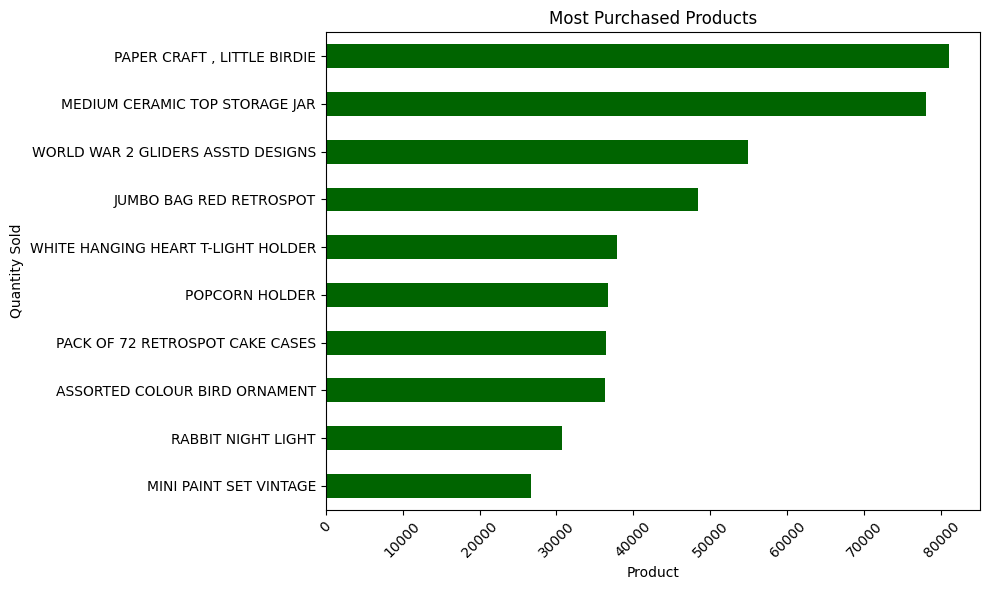

In [40]:
plt.figure(figsize=(10,6))

top_products.plot(kind='barh', color='darkgreen')

plt.title('Most Purchased Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Findings

PAPER CRAFT, LITTLE BIRDIE was the highest-selling product by quantity.

The chart highlights several products that consistently achieved strong sales volumes, indicating high customer demand for gift and decorative items.


## Visualization 2: Revenue by Country

This chart displays the top revenue generating countries.

The objective is to understand geographic revenue distribution and identify key markets.


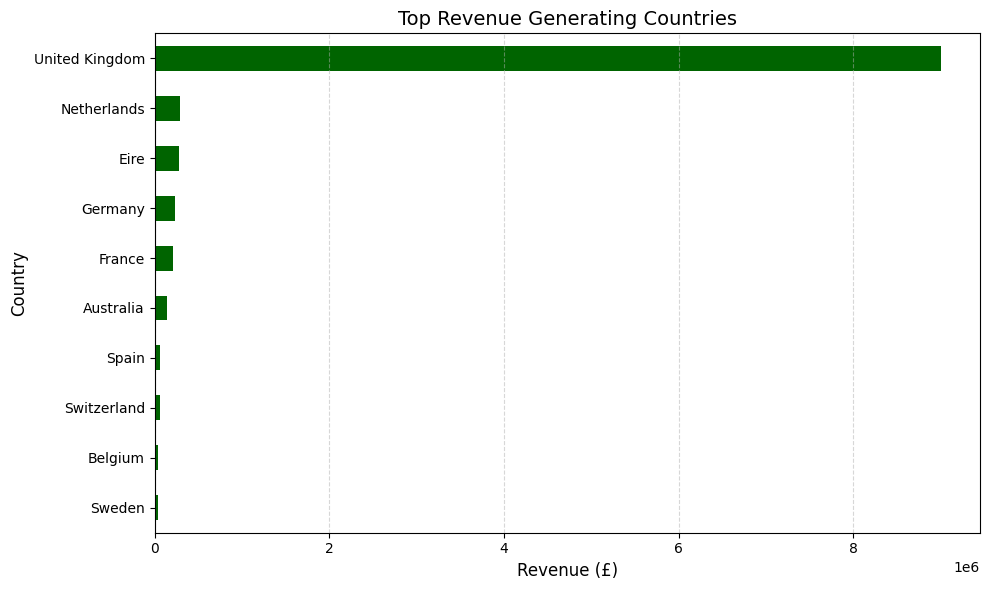

In [41]:
# Revenue by Country

plt.figure(figsize=(10,6))

top_countries.plot(
    kind='barh',
    color='darkgreen'
)

plt.title('Top Revenue Generating Countries', fontsize=14)
plt.xlabel('Revenue (£)', fontsize=12)
plt.ylabel('Country', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

### Findings


The United Kingdom generated the highest revenue, contributing more than £9 million in sales and significantly outperforming all other countries.

The Netherlands, Eire, Germany, and France were the next highest revenue-generating markets, although their contributions were substantially lower. This indicates that the retailer's customer base is heavily concentrated within the United Kingdom, with international markets contributing a smaller share of overall revenue.


## Visualization 3: Monthly Revenue Trend

This line chart illustrates changes in revenue over time.

The visualization helps identify seasonal trends and periods of strong sales performance.


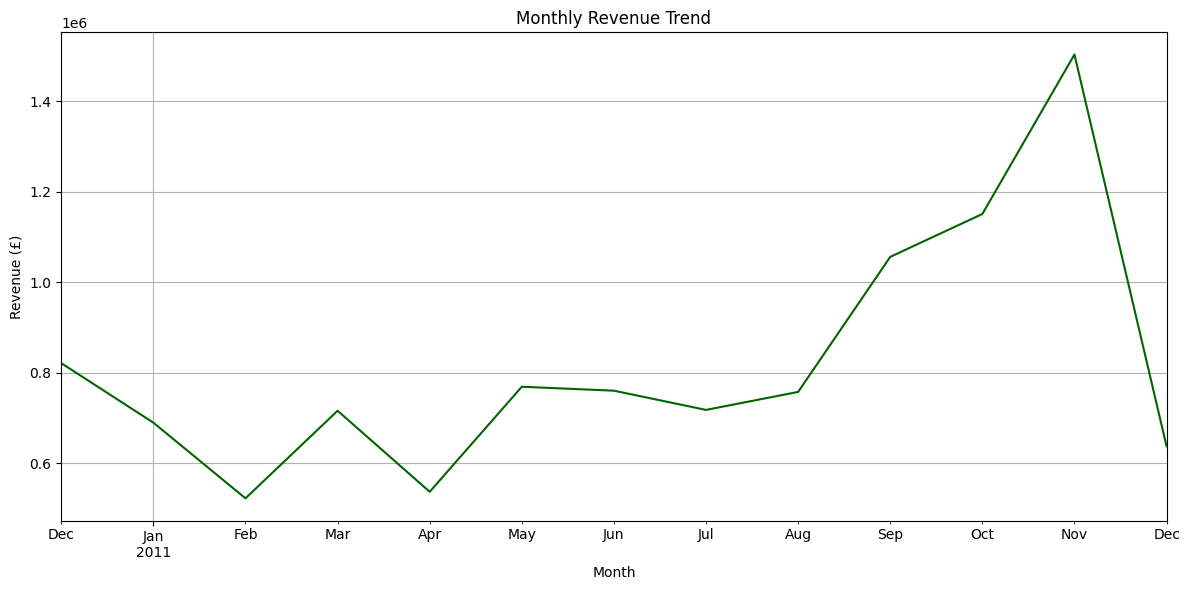

In [42]:
plt.figure(figsize=(12,6))

monthly_sales.plot(kind='line', color= 'darkgreen')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')

plt.grid(True)
plt.tight_layout()

plt.show()

### Findings

Revenue generally increased throughout 2011, with the highest revenue recorded in November 2011 at approximately £1.5 million.

The trend suggests strong seasonal demand toward the end of the year.


## Visualization 4: Top Revenue Generating Products

This visualization identifies the products that generated the highest revenue during the analysis period.

While sales quantity indicates product popularity, revenue highlights the products that contributed the most to the company's financial performance. This analysis helps identify high-value products and supports pricing, inventory, and product strategy decisions.


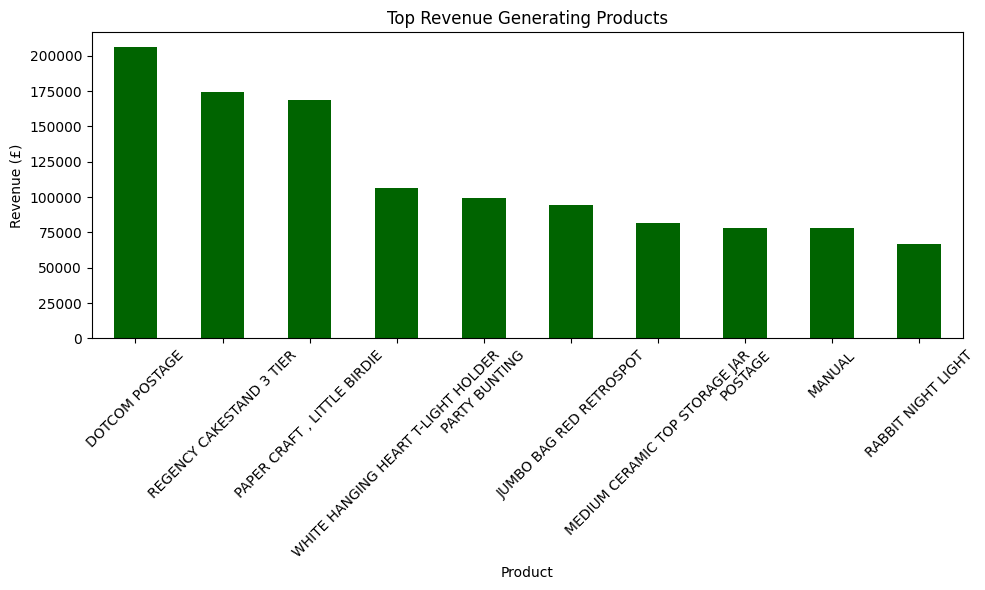

In [43]:
plt.figure(figsize=(10,6))

top_revenue_products.plot(kind='bar', color= 'darkgreen')

plt.title('Top Revenue Generating Products')
plt.xlabel('Product')
plt.ylabel('Revenue (£)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Findings

DOTCOM POSTAGE generated the highest revenue, followed by REGENCY CAKESTAND 3 TIER and PAPER CRAFT, LITTLE BIRDIE.

The results demonstrate that products with the highest revenue are not always the products with the highest sales volume, highlighting the importance of pricing in revenue generation.


## Visualization 5: Customer Purchasing Frequency Distribution

This box plot illustrates the distribution of customer order frequency across the dataset.

The objective is to understand customer purchasing behavior, identify typical order patterns, and detect highly active customers. Analyzing purchase frequency can provide insights into customer loyalty and purchasing habits.


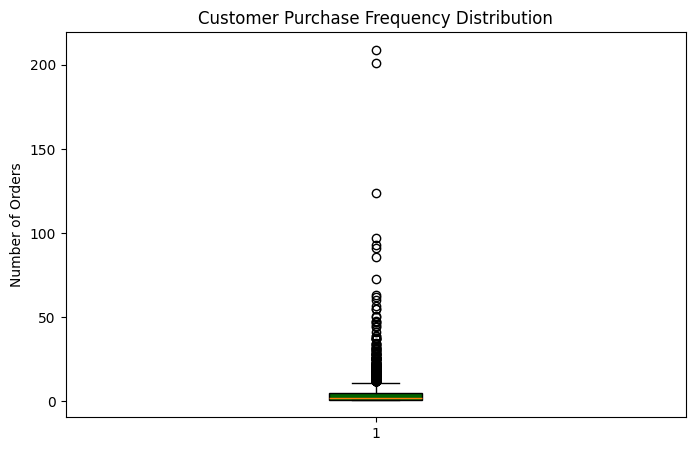

In [44]:
plt.figure(figsize=(8,5))

plt.boxplot(
    customer_orders,
    patch_artist=True,
    boxprops=dict(facecolor='darkgreen')
)

plt.title('Customer Purchase Frequency Distribution')
plt.ylabel('Number of Orders')

plt.show()

### Findings

Most customers placed a relatively small number of orders, as indicated by the concentration of observations near the lower end of the distribution.

The presence of numerous outliers suggests that a small group of customers made significantly more purchases than the average customer. These highly active customers represent an important segment that contributes substantially to overall sales activity.

The following insights were derived from the exploratory analysis and visualizations created during this project.

# Key Insights

### Insight 1: The United Kingdom Dominates Revenue Generation

The United Kingdom generated over £9 million in revenue, significantly outperforming all other countries. This indicates that the retailer's business is heavily concentrated within the UK market, making it the company's most important revenue source.

### Insight 2: Product Popularity Does Not Always Translate to Revenue Leadership

PAPER CRAFT, LITTLE BIRDIE was the most purchased product by quantity sold, while DOTCOM POSTAGE generated the highest revenue. This demonstrates that pricing plays a significant role in revenue generation and that high sales volume alone does not guarantee the highest revenue contribution.

### Insight 3: Revenue Peaks During the Holiday Season

Monthly sales reached their highest level in November 2011, generating approximately £1.5 million in revenue. This suggests strong seasonal demand and increased customer spending during the holiday shopping period.

### Insight 4: Customer Purchasing Activity Is Highly Concentrated

The majority of customers placed only a few orders, while a small group of customers completed significantly more transactions than average. These loyal customers contribute disproportionately to overall sales and represent an important customer segment for retention strategies.

### Insight 5: High-Value Products Drive Financial Performance

Products such as DOTCOM POSTAGE and REGENCY CAKESTAND 3 TIER generated substantial revenue despite not necessarily being the highest-selling products by quantity. This highlights the importance of monitoring both sales volume and revenue when evaluating product performance.


# Online Retail Data Cleaning and Exploratory Data Analysis Report

## Project Overview

This project involved cleaning, analyzing, and visualizing the Online Retail dataset to uncover sales trends, customer purchasing behavior, product performance, and revenue patterns. The dataset initially contained 541,909 transaction records and required extensive cleaning before analysis could be performed.

## Data Cleaning Challenges Encountered

Several data quality issues were identified during the cleaning process:

* Missing values were found in the Description and CustomerID columns.
* Duplicate transaction records were identified and removed.
* Cancelled transactions were detected through invoice numbers beginning with the letter "C".
* Records with non-positive unit prices were identified and removed.
* Column names, text fields, and date formats were standardized to ensure consistency.

These cleaning actions improved data quality and ensured that subsequent analyses were based on valid sales transactions.

## Key EDA Findings

The exploratory analysis revealed several important business patterns:

* PAPER CRAFT, LITTLE BIRDIE was the most purchased product based on quantity sold.
* DOTCOM POSTAGE generated the highest revenue among all products.
* The United Kingdom was the highest revenue-generating country, contributing more than £9 million in sales.
* Monthly revenue peaked in November 2011, generating approximately £1.5 million.
* Customer purchasing behavior was highly concentrated among a relatively small group of frequent buyers.

## Top Insights

1. The United Kingdom is the retailer's primary market and contributes the majority of total revenue.
2. Product popularity does not always translate into the highest revenue, as pricing significantly influences financial performance.
3. Revenue demonstrates strong seasonal patterns, with sales peaking during the holiday shopping period.
4. A small group of highly active customers contributes disproportionately to transaction volume.
5. High-value products play a critical role in overall business performance and should be monitored alongside sales volume metrics.

## Conclusion

The cleaned dataset provided valuable insights into customer behavior, product performance, sales trends, and revenue generation. The findings demonstrate how data analysis can support informed business decisions related to inventory management, customer retention, pricing strategies, and market expansion opportunities.
